# Model Performance Visualization (CPU Timing)

This notebook creates comprehensive visualizations of embedding model performance across different categories using CPU timing data.

## Metrics:
- **MRR (Mean Reciprocal Rank)**: Measures how high the first relevant result appears
- **NDCG (Normalized Discounted Cumulative Gain)**: Measures ranking quality with position-based weighting
- **Avg Time (ms)**: Average encoding time per abstract (CPU)

## Categories:
- **AI**: Artificial Intelligence papers
- **MilDec**: Military Decision Making papers
- **MilDec & AI**: Papers covering both domains
- **Unrelated**: Control group of unrelated papers


## 1. Setup and Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load and Prepare Data

In [25]:
# Load the CPU performance summary data from JSON
import json

json_path = Path("results_cpu_20260313_000833/summary.json")
with open(json_path, 'r') as f:
    cpu_data = json.load(f)

# Transform JSON data into the same DataFrame format as GPU data
rows = []
for model_data in cpu_data:
    # Extract short model name
    model_full = model_data['model']
    model_short = model_full.split('/')[-1] if '/' in model_full else model_full
    
    # Overall metrics
    rows.append({
        'Model': model_short,
        'Category': 'Overall',
        'MRR': model_data['avg_mrr'],
        'NDCG': model_data['avg_ndcg'],
        'Queries': model_data['queries_evaluated'],
        'Avg Time (ms)': model_data['avg_time_per_abstract_ms']
    })
    
    # Category-specific metrics
    for category, metrics in model_data['category_metrics'].items():
        rows.append({
            'Model': model_short,
            'Category': category,
            'MRR': metrics['avg_mrr'],
            'NDCG': metrics['avg_ndcg'],
            'Queries': metrics['queries_evaluated'],
            'Avg Time (ms)': model_data['avg_time_per_abstract_ms']  # Same across categories
        })

df = pd.DataFrame(rows)

# Convert metric columns to numeric
df['MRR'] = pd.to_numeric(df['MRR'])
df['NDCG'] = pd.to_numeric(df['NDCG'])
df['Avg Time (ms)'] = pd.to_numeric(df['Avg Time (ms)'], errors='coerce')

# Display the data
print(f"Data shape: {df.shape}")
print(f"\nModels evaluated: {df['Model'].nunique()}")
print(f"Categories: {df['Category'].nunique()}")
print("\nData Source: CPU Timing Results")
df.head(10)


Data shape: (30, 6)

Models evaluated: 6
Categories: 5

Data Source: CPU Timing Results


,Model,Category,MRR,NDCG,Queries,Avg Time (ms)
0,all-MiniLM-L6-v2,Overall,0.652778,0.914180,12,24.807028
1,all-MiniLM-L6-v2,AI,0.777778,0.900601,3,24.807028
2,all-MiniLM-L6-v2,MilDec,0.833333,0.964344,3,24.807028
3,all-MiniLM-L6-v2,MilDec & AI,1.000000,0.937609,3,24.807028
4,all-MiniLM-L6-v2,Unrelated,0.000000,0.854165,3,24.807028
5,rubert-tiny2,Overall,0.386111,0.770374,12,11.561636
6,rubert-tiny2,AI,0.583333,0.766265,3,11.561636
7,rubert-tiny2,MilDec,0.700000,0.797045,3,11.561636
8,rubert-tiny2,MilDec & AI,0.261111,0.713116,3,11.561636
9,rubert-tiny2,Unrelated,0.000000,0.805071,3,11.561636


In [26]:
# Separate overall and category-specific performance
overall_df = df[df['Category'] == 'Overall'].copy()
category_df = df[df['Category'] != 'Overall'].copy()

model_order = [
    'all-MiniLM-L6-v2',
    'rubert-tiny2', 
    'gte-base-en-v1.5',
    'USER-bge-m3',
    'Qwen3-Embedding-0.6B',
    'jina-code-embeddings-1.5b'
]

# Reindex the dataframe to follow the specified order
overall_df = overall_df.set_index('Model').loc[model_order].reset_index()

print("Overall Performance (ordered by input context size):")
display(overall_df[['Model', 'MRR', 'NDCG', 'Avg Time (ms)']])

Overall Performance (ordered by input context size):


,Model,MRR,NDCG,Avg Time (ms)
0,all-MiniLM-L6-v2,0.652778,0.914180,24.807028
1,rubert-tiny2,0.386111,0.770374,11.561636
2,gte-base-en-v1.5,0.567593,0.766099,163.576832
3,USER-bge-m3,0.666667,0.900133,386.396089
4,Qwen3-Embedding-0.6B,0.625000,0.883931,2831.954717
5,jina-code-embeddings-1.5b,0.652778,0.912991,6880.592309


## 3. Overall Performance Comparison

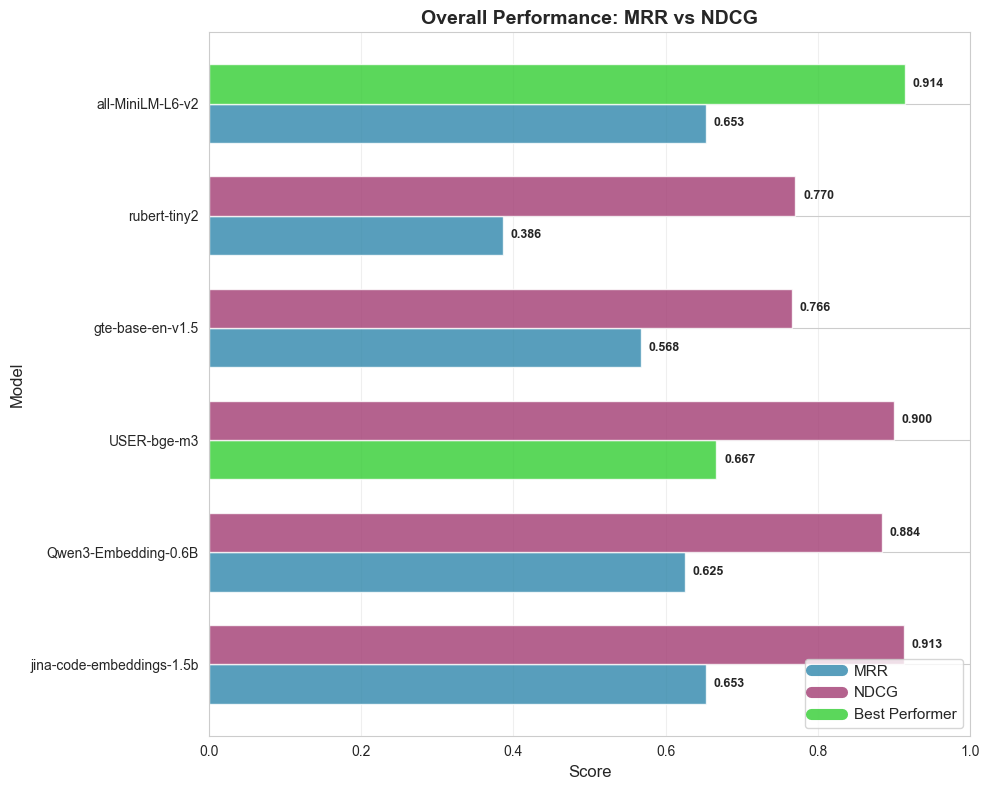

In [27]:
# Overall Performance: MRR vs NDCG (Horizontal Bar Chart)
# Reorder models from smallest to largest input context

fig, ax = plt.subplots(figsize=(10, 8))

# Reverse the order so models appear top-to-bottom
overall_df_reversed = overall_df.iloc[::-1].reset_index(drop=True)

y = np.arange(len(overall_df_reversed))
height = 0.35

# Find best MRR and NDCG
best_mrr_idx = overall_df_reversed['MRR'].idxmax()
best_ndcg_idx = overall_df_reversed['NDCG'].idxmax()

# Create color arrays - green for best performers, default colors otherwise
mrr_colors = ['limegreen' if i == best_mrr_idx else '#2E86AB' for i in range(len(overall_df_reversed))]
ndcg_colors = ['limegreen' if i == best_ndcg_idx else '#A23B72' for i in range(len(overall_df_reversed))]

# Create bars with color highlighting for best performers
bars1 = ax.barh(y - height/2, overall_df_reversed['MRR'], height, alpha=0.8, color=mrr_colors)
bars2 = ax.barh(y + height/2, overall_df_reversed['NDCG'], height, alpha=0.8, color=ndcg_colors)

ax.set_ylabel('Model', fontsize=12)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('Overall Performance: MRR vs NDCG', fontweight='bold', fontsize=14)
ax.set_yticks(y)
ax.set_yticklabels(overall_df_reversed['Model'])

# Add custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2E86AB', lw=8, label='MRR', alpha=0.8),
    Line2D([0], [0], color='#A23B72', lw=8, label='NDCG', alpha=0.8),
    Line2D([0], [0], color='limegreen', lw=8, label='Best Performer', alpha=0.8)
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, bars in enumerate([bars1, bars2]):
    for j, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}',
                ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Performance Heatmaps by Category

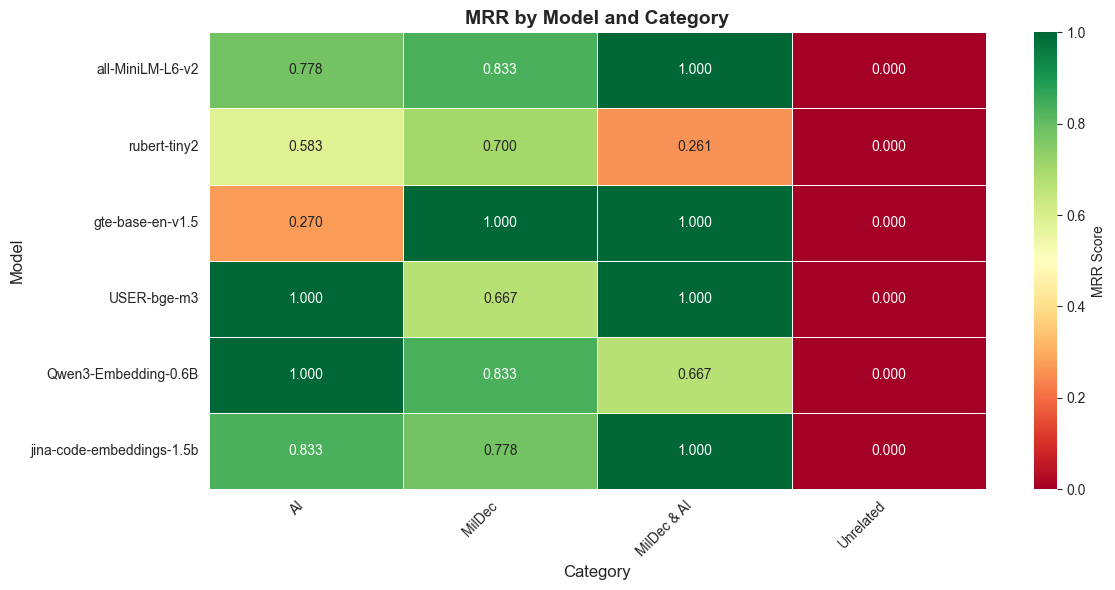

In [28]:
# MRR Heatmap by Category
fig, ax = plt.subplots(figsize=(12, 6))

# Flip axes: Models on rows, Categories on columns
mrr_pivot = category_df.pivot(index='Model', columns='Category', values='MRR')
# Reorder models to match our specified order
mrr_pivot = mrr_pivot.loc[model_order]

sns.heatmap(mrr_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, 
            cbar_kws={'label': 'MRR Score'}, vmin=0, vmax=1.0, linewidths=0.5)

ax.set_title('MRR by Model and Category', fontweight='bold', fontsize=14)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

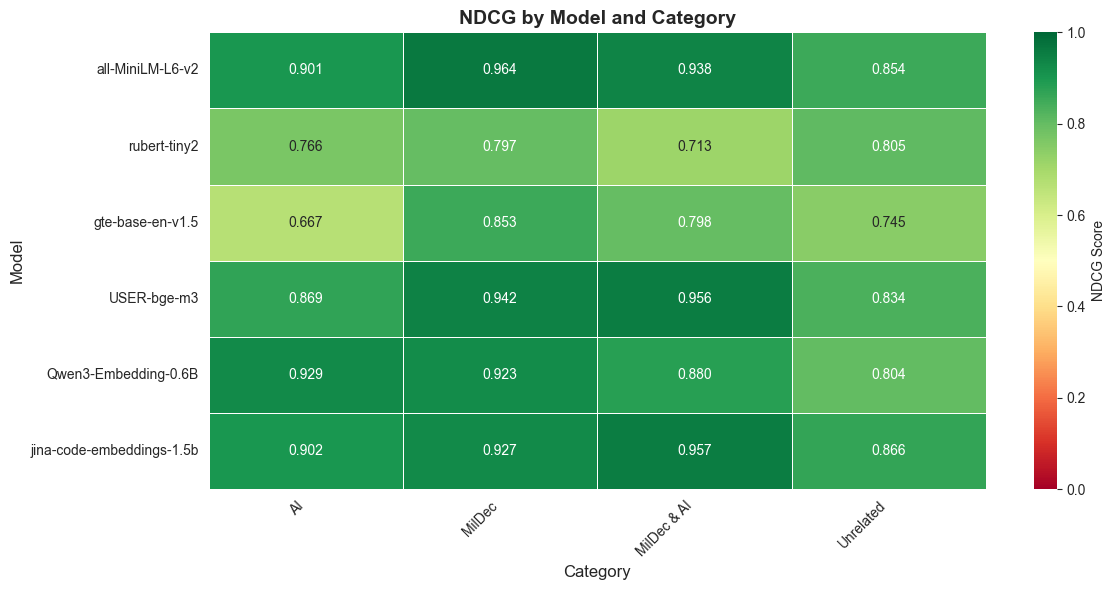

In [29]:
# NDCG Heatmap by Category
fig, ax = plt.subplots(figsize=(12, 6))

# Flip axes: Models on rows, Categories on columns
ndcg_pivot = category_df.pivot(index='Model', columns='Category', values='NDCG')
# Reorder models to match our specified order
ndcg_pivot = ndcg_pivot.loc[model_order]

sns.heatmap(ndcg_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            cbar_kws={'label': 'NDCG Score'}, vmin=0, vmax=1.0, linewidths=0.5)

ax.set_title('NDCG by Model and Category', fontweight='bold', fontsize=14)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Speed vs Performance Trade-offs

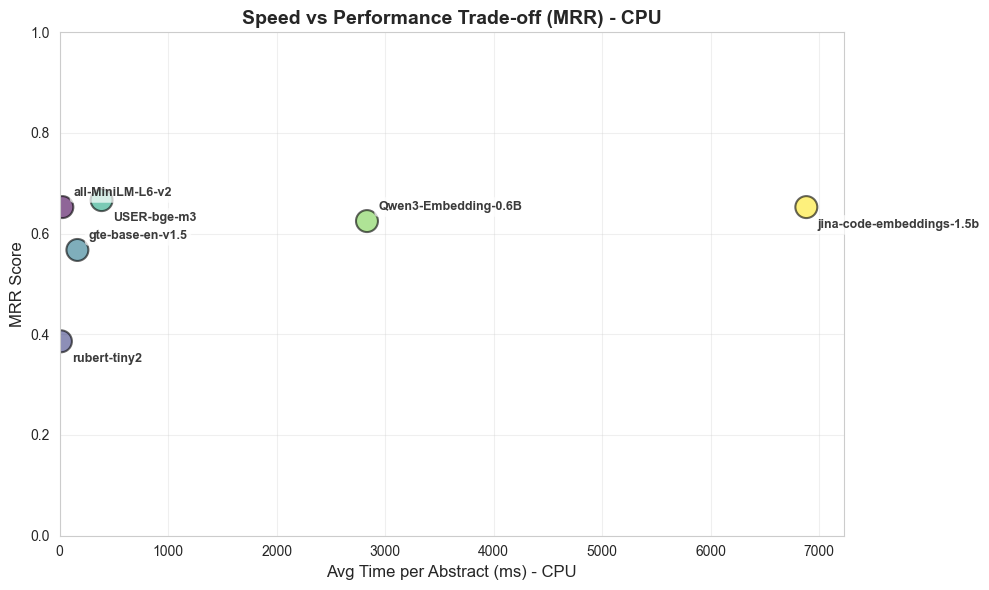

In [33]:
# Speed vs Performance (MRR) - CPU Timing
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(overall_df['Avg Time (ms)'], overall_df['MRR'], 
                     s=250, alpha=0.6, c=range(len(overall_df)), cmap='viridis', edgecolors='black', linewidth=1.5)

# Use smart positioning to avoid label overlaps
texts = []
for i, (idx, row) in enumerate(overall_df.iterrows()):
    # Position labels based on their location to minimize overlap
    if i % 2 == 0:
        xytext = (8, 8)
    else:
        xytext = (8, -15)
    
    texts.append(ax.annotate(row['Model'], 
                (row['Avg Time (ms)'], row['MRR']),
                xytext=xytext, textcoords='offset points',
                fontsize=9, alpha=0.9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7)))

ax.set_xlabel('Avg Time per Abstract (ms) - CPU', fontsize=12)
ax.set_ylabel('MRR Score', fontsize=12)
ax.set_title('Speed vs Performance Trade-off (MRR) - CPU', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


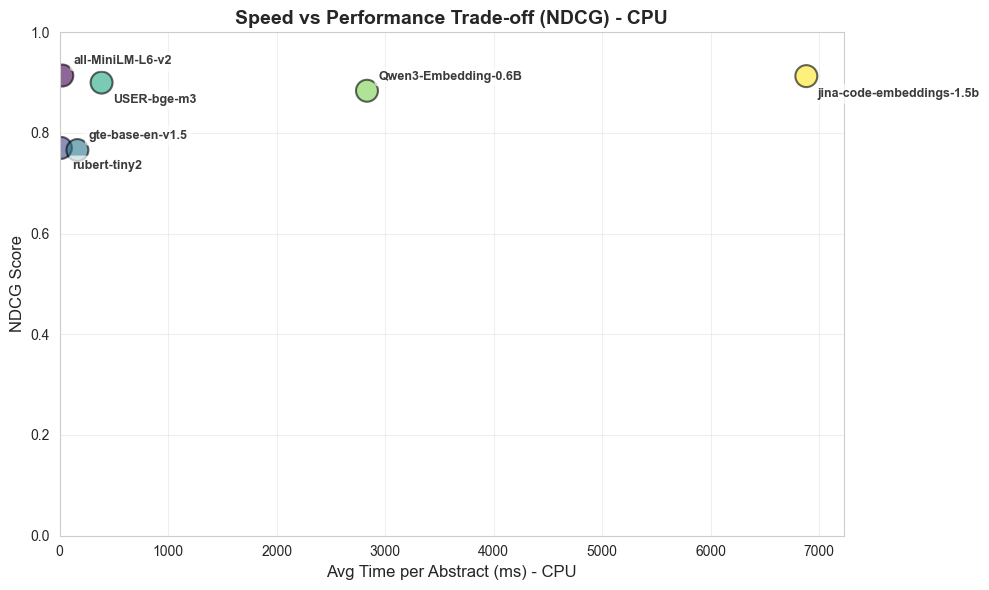

In [34]:
# Speed vs Performance (NDCG) - CPU Timing
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(overall_df['Avg Time (ms)'], overall_df['NDCG'], 
                     s=250, alpha=0.6, c=range(len(overall_df)), cmap='viridis', edgecolors='black', linewidth=1.5)

# Use smart positioning to avoid label overlaps
texts = []
for i, (idx, row) in enumerate(overall_df.iterrows()):
    # Position labels based on their location to minimize overlap
    if i % 2 == 0:
        xytext = (8, 8)
    else:
        xytext = (8, -15)
    
    texts.append(ax.annotate(row['Model'], 
                (row['Avg Time (ms)'], row['NDCG']),
                xytext=xytext, textcoords='offset points',
                fontsize=9, alpha=0.9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7)))

ax.set_xlabel('Avg Time per Abstract (ms) - CPU', fontsize=12)
ax.set_ylabel('NDCG Score', fontsize=12)
ax.set_title('Speed vs Performance Trade-off (NDCG) - CPU', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


## 6. Category Performance Breakdown

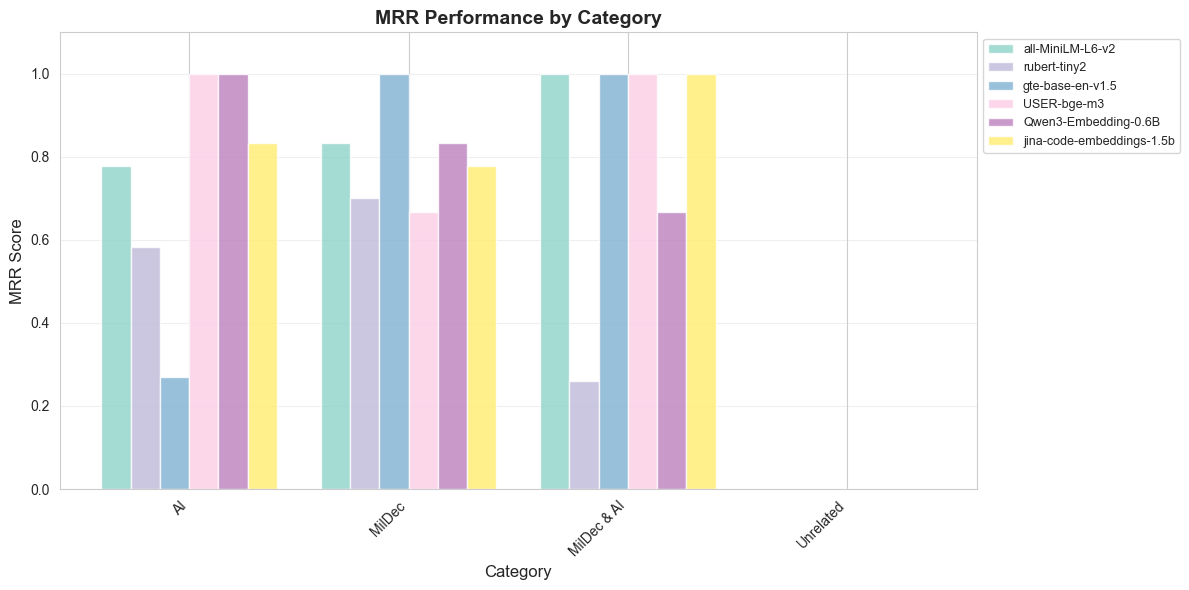

In [17]:
# MRR Performance by Category (Grouped Bar Chart)
fig, ax = plt.subplots(figsize=(12, 6))

categories = category_df['Category'].unique()
models = model_order  # Use the specified model order
x = np.arange(len(categories))
width = 0.8 / len(models)

colors = plt.cm.Set3(np.linspace(0, 1, len(models)))

for i, model in enumerate(models):
    model_data = category_df[category_df['Model'] == model]
    mrr_values = [model_data[model_data['Category'] == cat]['MRR'].values[0] 
                  if len(model_data[model_data['Category'] == cat]) > 0 else 0
                  for cat in categories]
    ax.bar(x + i * width, mrr_values, width, label=model, alpha=0.8, color=colors[i])

ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('MRR Score', fontsize=12)
ax.set_title('MRR Performance by Category', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=9, bbox_to_anchor=(1, 1))
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 7. Model Rankings

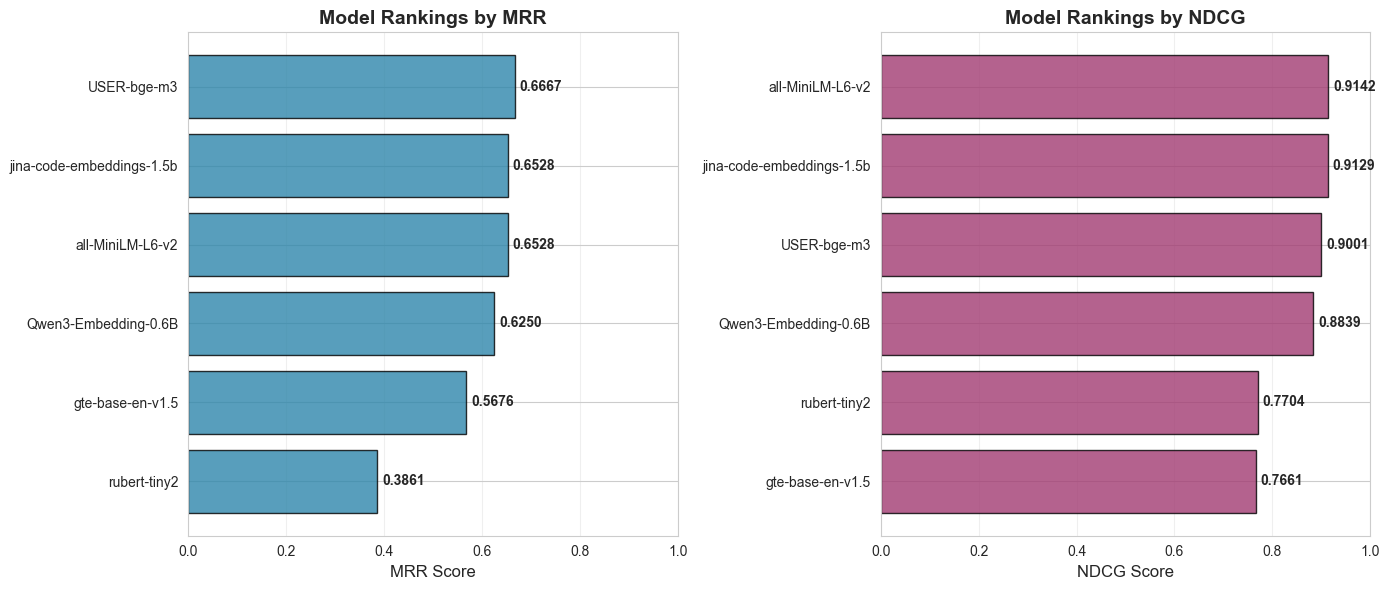

In [18]:
# Model Rankings (Horizontal Bar Charts)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Rank by MRR
overall_sorted_mrr = overall_df.sort_values('MRR', ascending=True)
axes[0].barh(range(len(overall_sorted_mrr)), overall_sorted_mrr['MRR'], 
             color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1)
axes[0].set_yticks(range(len(overall_sorted_mrr)))
axes[0].set_yticklabels(overall_sorted_mrr['Model'])
axes[0].set_xlabel('MRR Score', fontsize=12)
axes[0].set_title('Model Rankings by MRR', fontweight='bold', fontsize=14)
axes[0].set_xlim(0, 1.0)
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(overall_sorted_mrr.iterrows()):
    axes[0].text(row['MRR'] + 0.01, i, f"{row['MRR']:.4f}", 
                va='center', fontsize=10, fontweight='bold')

# Rank by NDCG
overall_sorted_ndcg = overall_df.sort_values('NDCG', ascending=True)
axes[1].barh(range(len(overall_sorted_ndcg)), overall_sorted_ndcg['NDCG'],
             color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)
axes[1].set_yticks(range(len(overall_sorted_ndcg)))
axes[1].set_yticklabels(overall_sorted_ndcg['Model'])
axes[1].set_xlabel('NDCG Score', fontsize=12)
axes[1].set_title('Model Rankings by NDCG', fontweight='bold', fontsize=14)
axes[1].set_xlim(0, 1.0)
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(overall_sorted_ndcg.iterrows()):
    axes[1].text(row['NDCG'] + 0.01, i, f"{row['NDCG']:.4f}",
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Comprehensive Overview (All Charts)

Charts saved to: results_gpu_20260312_235702\performance_charts.png


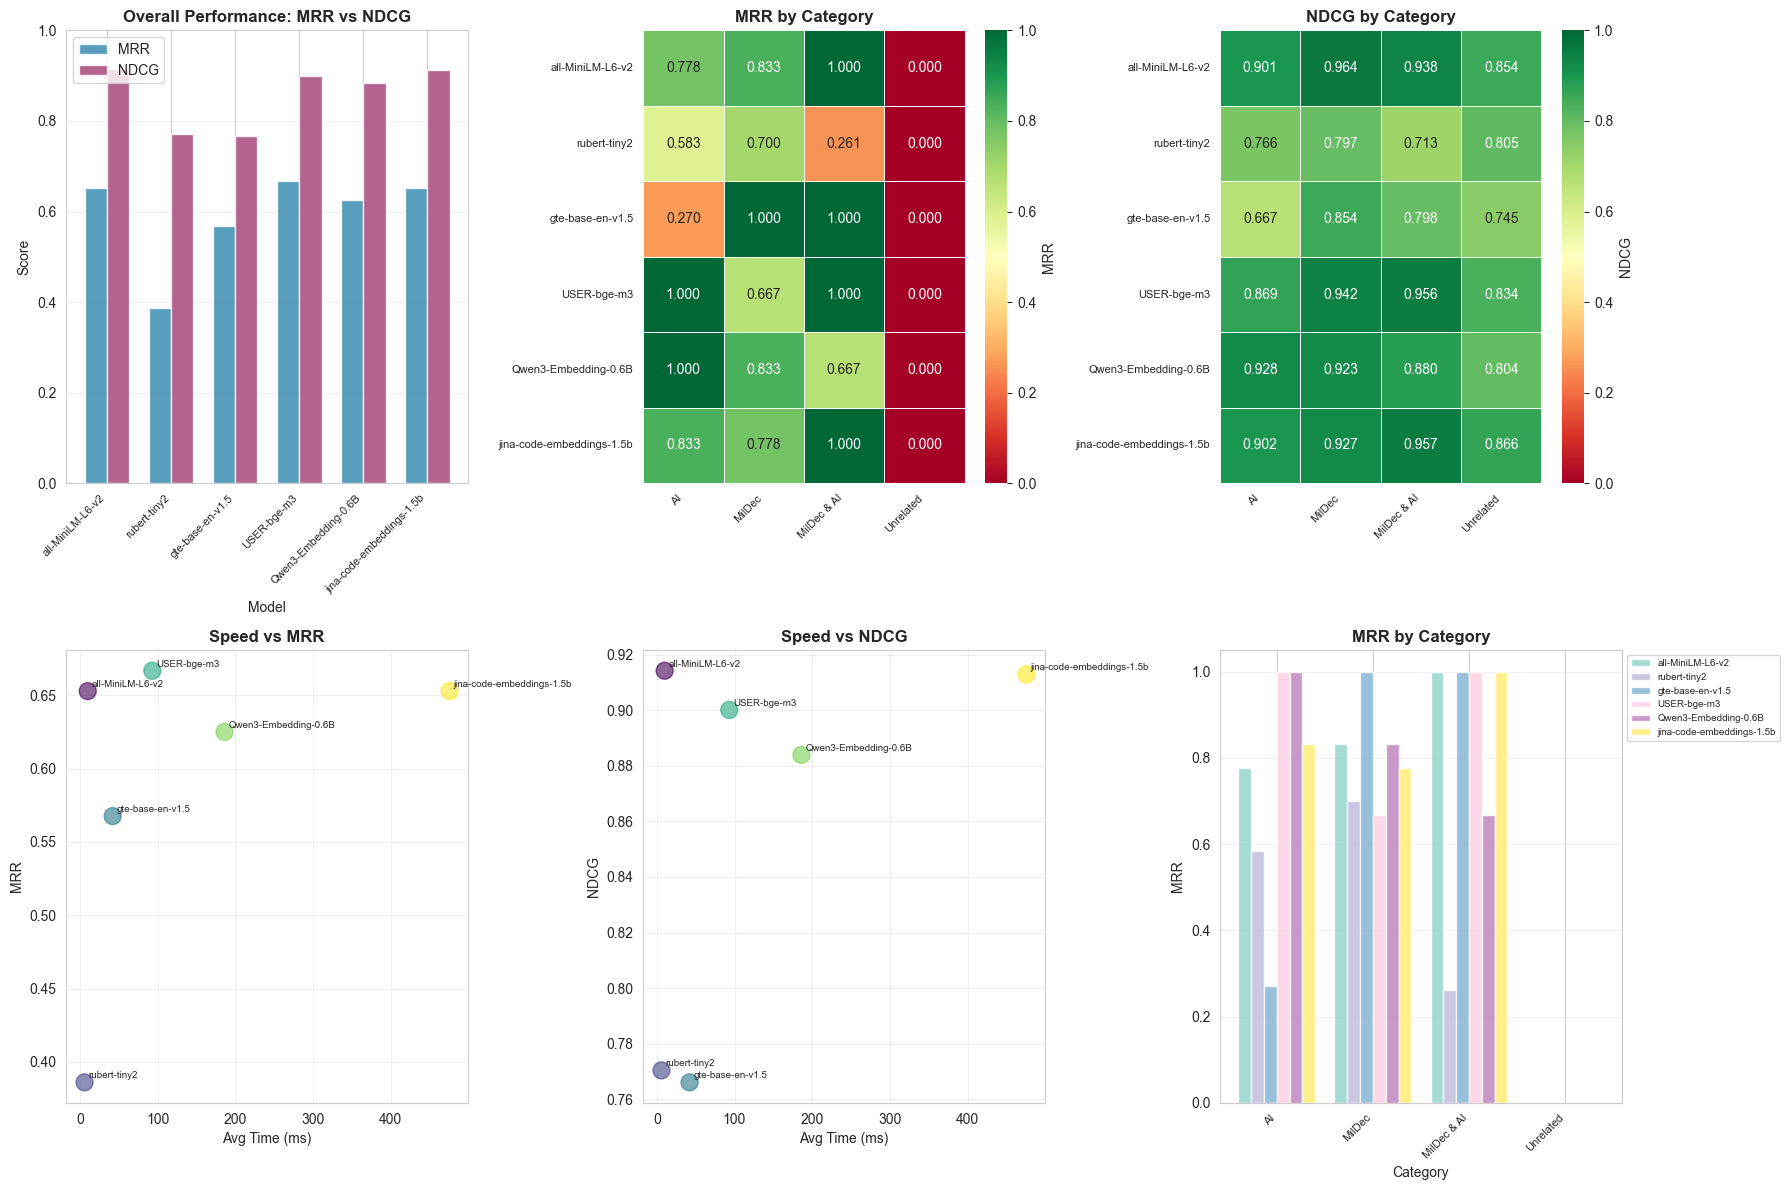

In [ ]:
# Create comprehensive figure with all charts
fig = plt.figure(figsize=(18, 12))

# 1. Overall Performance Comparison
ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(overall_df))
width = 0.35
bars1 = ax1.bar(x - width/2, overall_df['MRR'], width, label='MRR', alpha=0.8, color='#2E86AB')
bars2 = ax1.bar(x + width/2, overall_df['NDCG'], width, label='NDCG', alpha=0.8, color='#A23B72')
ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('Overall Performance: MRR vs NDCG', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(overall_df['Model'], rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', alpha=0.3)

# 2. MRR Heatmap
ax2 = plt.subplot(2, 3, 2)
mrr_pivot = category_df.pivot(index='Model', columns='Category', values='MRR')
mrr_pivot = mrr_pivot.loc[model_order]
sns.heatmap(mrr_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax2, 
            cbar_kws={'label': 'MRR'}, vmin=0, vmax=1.0, linewidths=0.5)
ax2.set_title('MRR by Category', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax2.get_yticklabels(), fontsize=8)

# 3. NDCG Heatmap
ax3 = plt.subplot(2, 3, 3)
ndcg_pivot = category_df.pivot(index='Model', columns='Category', values='NDCG')
ndcg_pivot = ndcg_pivot.loc[model_order]
sns.heatmap(ndcg_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax3,
            cbar_kws={'label': 'NDCG'}, vmin=0, vmax=1.0, linewidths=0.5)
ax3.set_title('NDCG by Category', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax3.get_yticklabels(), fontsize=8)

# 4. Speed vs MRR
ax4 = plt.subplot(2, 3, 4)
scatter = ax4.scatter(overall_df['Avg Time (ms)'], overall_df['MRR'], 
                     s=150, alpha=0.6, c=range(len(overall_df)), cmap='viridis')
for idx, row in overall_df.iterrows():
    ax4.annotate(row['Model'], (row['Avg Time (ms)'], row['MRR']),
                xytext=(3, 3), textcoords='offset points', fontsize=7)
ax4.set_xlabel('Avg Time (ms)')
ax4.set_ylabel('MRR')
ax4.set_title('Speed vs MRR', fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Speed vs NDCG
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(overall_df['Avg Time (ms)'], overall_df['NDCG'], 
                     s=150, alpha=0.6, c=range(len(overall_df)), cmap='viridis')
for idx, row in overall_df.iterrows():
    ax5.annotate(row['Model'], (row['Avg Time (ms)'], row['NDCG']),
                xytext=(3, 3), textcoords='offset points', fontsize=7)
ax5.set_xlabel('Avg Time (ms)')
ax5.set_ylabel('NDCG')
ax5.set_title('Speed vs NDCG', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Category Breakdown
ax6 = plt.subplot(2, 3, 6)
categories = category_df['Category'].unique()
models = model_order
x = np.arange(len(categories))
width = 0.8 / len(models)
colors = plt.cm.Set3(np.linspace(0, 1, len(models)))
for i, model in enumerate(models):
    model_data = category_df[category_df['Model'] == model]
    mrr_values = [model_data[model_data['Category'] == cat]['MRR'].values[0] 
                  if len(model_data[model_data['Category'] == cat]) > 0 else 0
                  for cat in categories]
    ax6.bar(x + i * width, mrr_values, width, label=model, alpha=0.8, color=colors[i])
ax6.set_xlabel('Category')
ax6.set_ylabel('MRR')
ax6.set_title('MRR by Category', fontweight='bold')
ax6.set_xticks(x + width * (len(models) - 1) / 2)
ax6.set_xticklabels(categories, rotation=45, ha='right', fontsize=8)
ax6.legend(loc='upper left', fontsize=7, bbox_to_anchor=(1, 1))
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save the figure to CPU results folder
output_path = Path("results_cpu_20260313_000833/performance_charts.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Charts saved to: {output_path}")

plt.show()


## 9. Summary Statistics

In [20]:
# Display summary statistics
print("=" * 80)
print("PERFORMANCE SUMMARY")
print("=" * 80)

print("\nTop 3 Models by NDCG:")
print("-" * 80)
top_ndcg = overall_df.nlargest(3, 'NDCG')[['Model', 'NDCG', 'MRR', 'Avg Time (ms)']]
for idx, row in top_ndcg.iterrows():
    print(f"{row['Model']:30s} | NDCG: {row['NDCG']:.4f} | MRR: {row['MRR']:.4f} | Time: {row['Avg Time (ms)']:.2f}ms")

print("\nTop 3 Models by MRR:")
print("-" * 80)
top_mrr = overall_df.nlargest(3, 'MRR')[['Model', 'MRR', 'NDCG', 'Avg Time (ms)']]
for idx, row in top_mrr.iterrows():
    print(f"{row['Model']:30s} | MRR: {row['MRR']:.4f} | NDCG: {row['NDCG']:.4f} | Time: {row['Avg Time (ms)']:.2f}ms")

print("\nFastest 3 Models:")
print("-" * 80)
fastest = overall_df.nsmallest(3, 'Avg Time (ms)')[['Model', 'Avg Time (ms)', 'NDCG', 'MRR']]
for idx, row in fastest.iterrows():
    print(f"{row['Model']:30s} | Time: {row['Avg Time (ms)']:.2f}ms | NDCG: {row['NDCG']:.4f} | MRR: {row['MRR']:.4f}")

print("\n" + "=" * 80)

PERFORMANCE SUMMARY

Top 3 Models by NDCG:
--------------------------------------------------------------------------------
all-MiniLM-L6-v2               | NDCG: 0.9142 | MRR: 0.6528 | Time: 10.04ms
jina-code-embeddings-1.5b      | NDCG: 0.9129 | MRR: 0.6528 | Time: 476.03ms
USER-bge-m3                    | NDCG: 0.9001 | MRR: 0.6667 | Time: 93.23ms

Top 3 Models by MRR:
--------------------------------------------------------------------------------
USER-bge-m3                    | MRR: 0.6667 | NDCG: 0.9001 | Time: 93.23ms
all-MiniLM-L6-v2               | MRR: 0.6528 | NDCG: 0.9142 | Time: 10.04ms
jina-code-embeddings-1.5b      | MRR: 0.6528 | NDCG: 0.9129 | Time: 476.03ms

Fastest 3 Models:
--------------------------------------------------------------------------------
rubert-tiny2                   | Time: 5.93ms | NDCG: 0.7704 | MRR: 0.3861
all-MiniLM-L6-v2               | Time: 10.04ms | NDCG: 0.9142 | MRR: 0.6528
gte-base-en-v1.5               | Time: 42.14ms | NDCG: 0.7661 | 